# Ejercicio 4 — Tabla de frecuencias por altura

---

> **Teniendo en cuenta la variable `altura_m` que se encuentra en el dataset `pacientes.csv` trabajado en el Ejercicio N°2, genere una tabla de frecuencias en la que las observaciones se encuentren segmentadas en subintervalos de 10 cm de amplitud que estén "cerrados por izquierda", es decir, que tengan la forma `[extremo_inferior, extremo_superior)`.**
>
> **La tabla de frecuencias generada deberá contener columnas en las que se especifiquen las frecuencias absolutas, relativas y relativas acumuladas correspondientes a cada subintervalo.**
>
> **¿Qué porcentaje de las personas del dataset tienen una altura menor a 1.8 m?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
pacientes = pd.read_csv('../Datasets/pacientes.csv', sep=';', decimal=',')
pacientes.columns = pacientes.columns.str.strip()
print(f'Shape: {pacientes.shape}')
print(f'Tipo de altura_m: {pacientes["altura_m"].dtype}')
print(f'Rango de altura: {pacientes["altura_m"].min():.2f} — {pacientes["altura_m"].max():.2f} m')
pacientes[['codigo_paciente', 'altura_m']].head()

Shape: (50, 6)
Tipo de altura_m: float64
Rango de altura: 1.50 — 1.90 m


,codigo_paciente,altura_m
0,398911,1.80
1,398912,1.75
2,398913,1.85
3,398914,1.65
4,398915,1.55


## Construcción de la tabla de frecuencias

Intervalos de 10 cm = 0.10 m, **cerrados por izquierda** `[a, b)` (`right=False` en `pd.cut`).

In [3]:
altura = pacientes['altura_m']

# Límites: múltiplos de 0.10 que encierren el rango completo
lim_inf = np.floor(altura.min() * 10) / 10
lim_sup = np.ceil(altura.max() * 10) / 10
bins = np.arange(lim_inf, lim_sup + 0.10, 0.10).round(2)
print(f'Límites: {bins}')

# right=False => [a, b)  (cerrado por izquierda)
categorias = pd.cut(altura, bins=bins, right=False)

freq_abs = categorias.value_counts().sort_index()
freq_rel = (freq_abs / len(altura) * 100).round(2)
freq_acum = freq_rel.cumsum().round(2)

tabla = pd.DataFrame({
    'Intervalo': freq_abs.index.astype(str),
    'Freq. absoluta': freq_abs.values,
    'Freq. relativa (%)': freq_rel.values,
    'Freq. relativa acumulada (%)': freq_acum.values
})
tabla

Límites: [1.5 1.6 1.7 1.8 1.9]


,Intervalo,Freq. absoluta,Freq. relativa (%),Freq. relativa acumulada (%)
0,"[1.5, 1.6)",12,24.0,24.0
1,"[1.6, 1.7)",17,34.0,58.0
2,"[1.7, 1.8)",12,24.0,82.0
3,"[1.8, 1.9)",7,14.0,96.0


In [4]:
umbral = 1.80
pct_menos_180 = (altura < umbral).sum() / len(altura) * 100
print(f'Porcentaje de personas con altura menor a {umbral} m: {pct_menos_180:.2f}%')

Porcentaje de personas con altura menor a 1.8 m: 82.00%


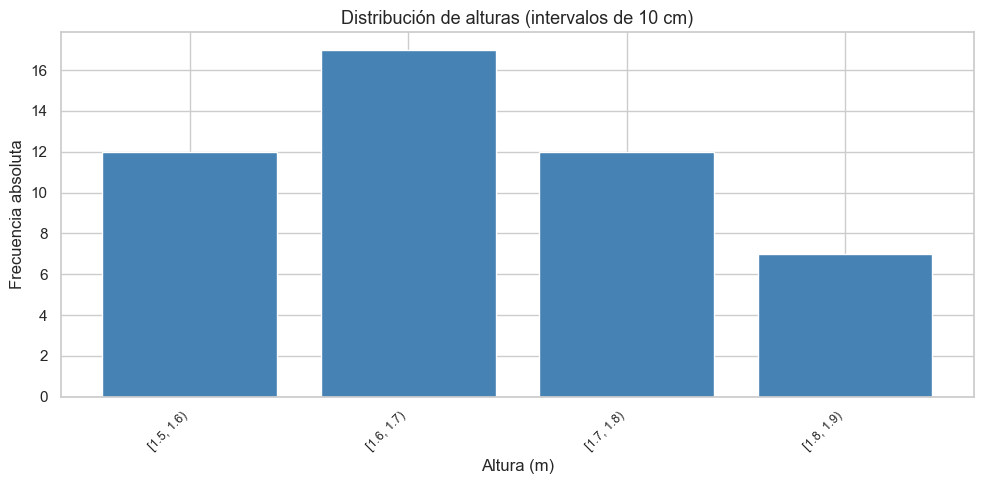

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    range(len(freq_abs)),
    freq_abs.values,
    color='steelblue',
    edgecolor='white'
)
ax.set_xticks(range(len(freq_abs)))
ax.set_xticklabels(tabla['Intervalo'], rotation=45, ha='right', fontsize=9)
ax.set_title('Distribución de alturas (intervalos de 10 cm)', fontsize=13)
ax.set_xlabel('Altura (m)')
ax.set_ylabel('Frecuencia absoluta')
plt.tight_layout()
plt.show()